In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

2026-05-07 15:06:22.931237: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778166383.126673      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778166383.186239      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778166383.661059      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778166383.661101      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778166383.661104      57 computation_placer.cc:177] computation placer alr

In [2]:
RAF_BASIC_DIR = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"

TRAIN_DIR = os.path.join(RAF_BASIC_DIR, "train")
TEST_DIR = os.path.join(RAF_BASIC_DIR, "test")

IMG_SIZE = 100
BATCH_SIZE = 64
SEED = 42
NUM_CLASSES = 7

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))

print("Train folders:", os.listdir(TRAIN_DIR) if os.path.exists(TRAIN_DIR) else "Not found")
print("Test folders:", os.listdir(TEST_DIR) if os.path.exists(TEST_DIR) else "Not found")

Train dir exists: True
Test dir exists: True
Train folders: ['7', '2', '5', '3', '1', '4', '6']
Test folders: ['7', '2', '5', '3', '1', '4', '6']


In [3]:
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset="training"
)

val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset="validation"
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Original class folders:", train_ds.class_names)

Found 12271 files belonging to 7 classes.
Using 9817 files for training.


I0000 00:00:1778166420.660431      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778166420.666519      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 12271 files belonging to 7 classes.
Using 2454 files for validation.
Found 3068 files belonging to 7 classes.
Original class folders: ['1', '2', '3', '4', '5', '6', '7']


In [4]:
class_names = [
    "surprise",
    "fear",
    "disgust",
    "happy",
    "sad",
    "angry",
    "neutral"
]

print("Class names:", class_names)

Class names: ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']


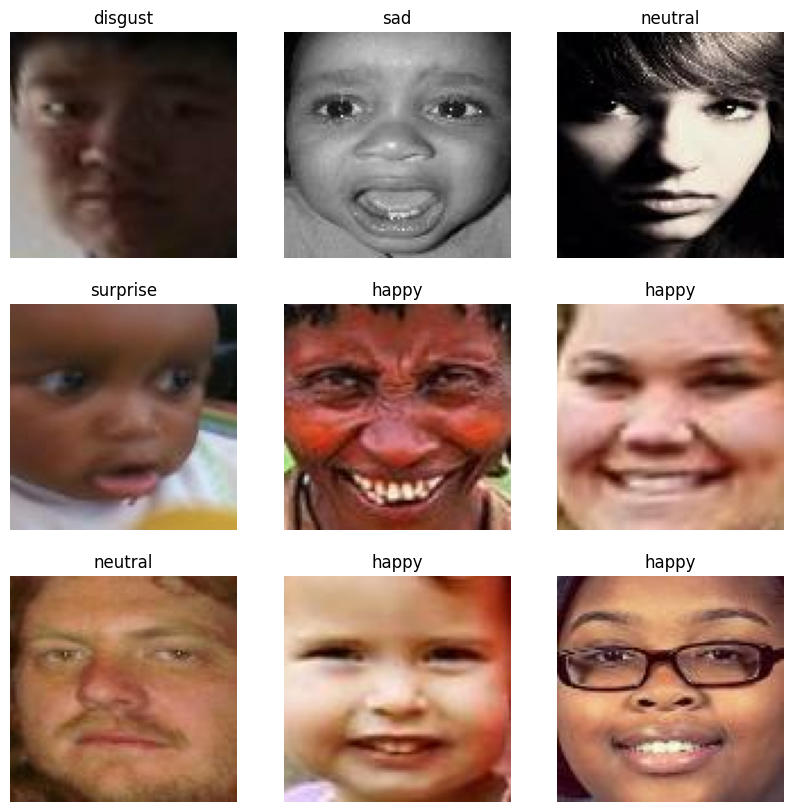

In [5]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.show()

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.06, 0.06),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [8]:
y_train = []

for _, labels in train_ds.unbatch():
    y_train.append(labels.numpy())

y_train = np.array(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    i: min(float(weight), 3.0)
    for i, weight in enumerate(class_weights_array)
}

print("Clipped class weights:")
for i, weight in class_weights.items():
    print(class_names[i], ":", weight)

Clipped class weights:
surprise : 1.3550034506556246
fear : 3.0
disgust : 2.4305521168606092
happy : 0.3664563813505543
sad : 0.8836979026014943
angry : 2.4560920690517887
neutral : 0.7058019987058739


In [9]:
def residual_block(x, filters, stride=1, dropout_rate=0.2, weight_decay=1e-4):
    shortcut = x

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        strides=stride,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        strides=1,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(
            filters,
            kernel_size=1,
            strides=stride,
            padding="same",
            use_bias=False,
            kernel_regularizer=regularizers.l2(weight_decay)
        )(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    return x

In [10]:
def build_raf_resnet_model(
    input_shape=(100, 100, 3),
    num_classes=7,
    weight_decay=1e-4
):
    inputs = layers.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 32, stride=1, dropout_rate=0.1, weight_decay=weight_decay)

    x = residual_block(x, 64, stride=2, dropout_rate=0.15, weight_decay=weight_decay)
    x = residual_block(x, 64, stride=1, dropout_rate=0.15, weight_decay=weight_decay)

    x = residual_block(x, 128, stride=2, dropout_rate=0.2, weight_decay=weight_decay)
    x = residual_block(x, 128, stride=1, dropout_rate=0.2, weight_decay=weight_decay)

    x = residual_block(x, 256, stride=2, dropout_rate=0.25, weight_decay=weight_decay)
    x = residual_block(x, 256, stride=1, dropout_rate=0.25, weight_decay=weight_decay)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="RAFDB_ResNet_Style_CNN")
    return model


model = build_raf_resnet_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES
)

model.summary()

Model: "RAFDB_ResNet_Style_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 100, 100,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 100, 100,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 100, 100,  │        864 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 100, 100,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 100, 100,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 100, 100,  │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 100, 100,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 100, 100,  │      9,216 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 100,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 100, 100,  │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 100, 100,  │          0 │ re_lu_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 50, 50,    │     18,432 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 50, 50,    │          0 │ batch_normalizat

 Total params: 2,849,767 (10.87 MB)

 Trainable params: 2,844,583 (10.85 MB)

 Non-trainable params: 5,184 (20.25 KB)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_rafdb_resnet_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [13]:
EPOCHS = 80

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/80


E0000 00:00:1778166454.923149      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/RAFDB_ResNet_Style_CNN_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1778166458.250536     114 cuda_dnn.cc:529] Loaded cuDNN version 91002


154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.2763 - loss: 2.3908
Epoch 1: val_accuracy improved from -inf to 0.38509, saving model to best_rafdb_resnet_model.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 66s 320ms/step - accuracy: 0.2765 - loss: 2.3898 - val_accuracy: 0.3851 - val_loss: 2.0254 - learning_rate: 5.0000e-04
Epoch 2/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.3900 - loss: 2.0073
Epoch 2: val_accuracy did not improve from 0.38509
154/154 ━━━━━━━━━━━━━━━━━━━━ 46s 299ms/step - accuracy: 0.3901 - loss: 2.0071 - val_accuracy: 0.2123 - val_loss: 2.1216 - learning_rate: 5.0000e-04
Epoch 3/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.4056 - loss: 1.9338
Epoch 3: val_accuracy did not improve from 0.38509
154/154 ━━━━━━━━━━━━━━━━━━━━ 46s 298ms/step - accuracy: 0.4057 - loss: 1.9336 - val_accuracy: 0.3741 - val_loss: 1.8907 - learning_rate: 5.0000e-04
Epoch 4/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.4307 - loss: 1.8527
Epoch 4: val_a

In [ ]:
# EPOCHS = 80

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=EPOCHS,
#     callbacks=callbacks,
#     class_weight=class_weights
# ) If you find that the recall of certain categories is very poor, run the second round and add clipped class weight：

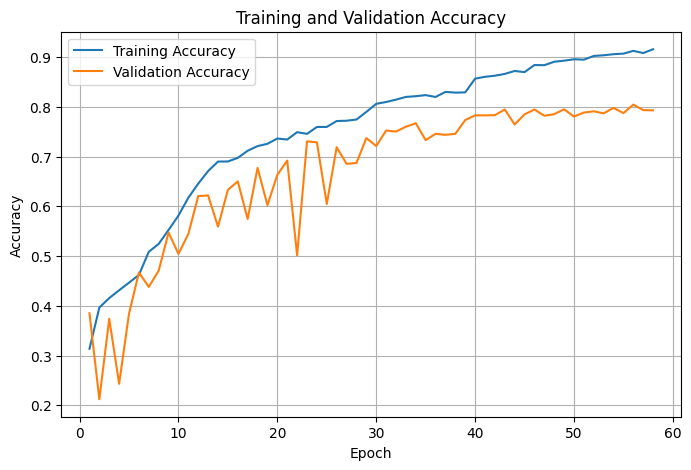

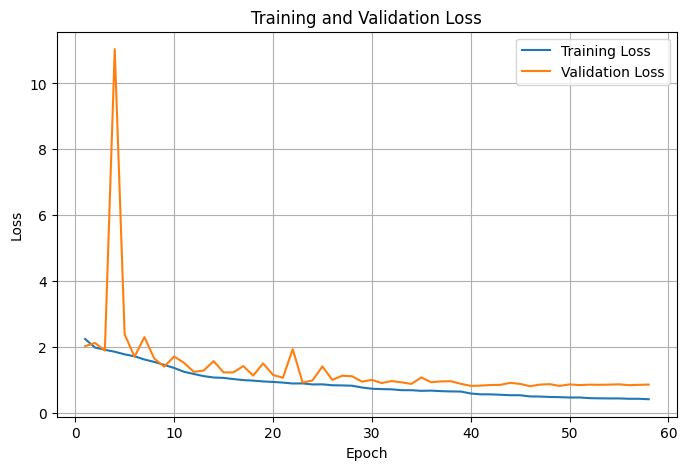

In [15]:
def plot_training_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_history(history)

In [16]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.7875 - loss: 0.9041
Test Loss: 0.7680348753929138
Test Accuracy: 0.8135592937469482


In [17]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

    surprise     0.8851    0.7964    0.8384       329
        fear     0.7736    0.5541    0.6457        74
     disgust     0.5714    0.4000    0.4706       160
       happy     0.9396    0.8928    0.9156      1185
         sad     0.7515    0.7908    0.7706       478
       angry     0.6923    0.7222    0.7069       162
     neutral     0.7120    0.8471    0.7737       680

    accuracy                         0.8136      3068
   macro avg     0.7608    0.7148    0.7316      3068
weighted avg     0.8177    0.8136    0.8126      3068



<Figure size 900x900 with 0 Axes>

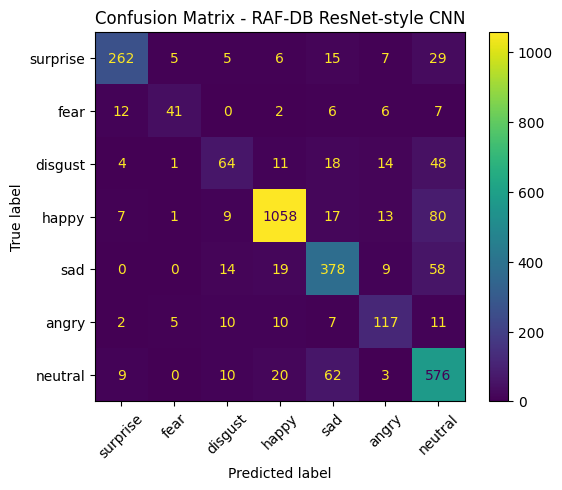

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - RAF-DB ResNet-style CNN")
plt.xticks(rotation=45)
plt.show()

In [19]:
model.save("final_rafdb_resnet_model.keras")
print("Model saved successfully.")

Model saved successfully.


In [20]:
loaded_model = tf.keras.models.load_model("final_rafdb_resnet_model.keras")
print("Model loaded successfully.")

Model loaded successfully.


In [21]:
from tensorflow.keras.utils import load_img, img_to_array

def predict_emotion_image(model, img_path, class_names):
    img = load_img(
        img_path,
        color_mode="rgb",
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)[0]
    pred_index = np.argmax(preds)
    pred_class = class_names[pred_index]
    confidence = preds[pred_index]

    plt.imshow(img_array[0].astype("uint8"))
    plt.title(f"Prediction: {pred_class} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    print("Prediction:", pred_class)
    print("Confidence:", confidence)

    for name, prob in zip(class_names, preds):
        print(f"{name}: {prob:.4f}")

    return pred_class, confidence

Sample image: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2941_aligned.jpg


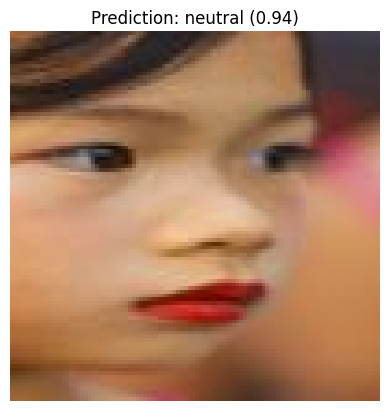

Prediction: neutral
Confidence: 0.9438715
surprise: 0.0003
fear: 0.0000
disgust: 0.0522
happy: 0.0001
sad: 0.0026
angry: 0.0009
neutral: 0.9439


('neutral', np.float32(0.9438715))

In [22]:
sample_img_path = None

for root, dirs, files in os.walk(TEST_DIR):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            sample_img_path = os.path.join(root, file)
            break
    if sample_img_path is not None:
        break

print("Sample image:", sample_img_path)

predict_emotion_image(model, sample_img_path, class_names)